## Meal & Grocery Planner With CrewAI

In [ ]:
# Importing required libraries
import os

from dotenv import load_dotenv
load_dotenv()
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from CrewAI.leftover import LeftoversCrew

from pydantic import BaseModel, Field
from typing import List, Dict, Optional
from IPython.display import display, JSON, Markdown
from datetime import datetime

In [6]:
# filein current directory
files = os.listdir('.')
print(files)

['leftover.py', 'Meal-&-Grocery-Planner-With-CrewAI.ipynb', 'Multi-Agent-AI-Automation-Using-CrewAI.ipynb', '__pycache__']


#### Creating the Grocery Shopping Assistant Structure

We are first creating the blueprint to manage the structure because when we are dealing with grocery lists, meal plans, and shopping data we need everything organized in a predictable format.

<b>GroceryItem

In [8]:
class GroceryItem(BaseModel):
    """Individual grocery item"""
    name: str = Field(description="Name of the grocery item")
    quantity: str = Field(description="Quantity needed (for example, '2 lbs', '1 gallon')")
    estimated_price: str = Field(description="Estimated price (for example, '$3-5')")
    category: str = Field(description="Store section (for example, 'Produce', 'Dairy')")

In [10]:
sample_item = GroceryItem(
    name="Chicken Breast",
    quantity="2 lbs",
    estimated_price="$8-12",
    category="Meat"
)
# Display structured data
print("🛒 Sample Grocery Item Structure:")
display(JSON(sample_item.model_dump()))

🛒 Sample Grocery Item Structure:


<IPython.core.display.JSON object>

<b>MealPlan

In [11]:
class MealPlan(BaseModel):
    """Simple meal plan"""
    meal_name: str = Field(description="Name of the meal")
    difficulty_level: str = Field(description="'Easy', 'Medium', 'Hard'")
    servings: int = Field(description="Number of people it serves")
    researched_ingredients: List[str] = Field(description="Ingredients found through research")

In [12]:
sample_meal = MealPlan(
    meal_name="Chicken Stir Fry",
    difficulty_level="Easy",
    servings=4,
    researched_ingredients=["chicken breast", "broccoli", "bell peppers", "garlic", "soy sauce", "rice"]
)

print("\n🍽️ Sample Meal Plan Structure:")
display(JSON(sample_meal.model_dump()))


🍽️ Sample Meal Plan Structure:


<IPython.core.display.JSON object>

<b>ShoppingCategory

In [13]:
class ShoppingCategory(BaseModel):
    """Store section with items"""
    section_name: str = Field(description="Store section (for example, 'Produce', 'Dairy')")
    items: List[GroceryItem] = Field(description="Items in this section")
    estimated_total: str = Field(description="Estimated cost for this section")

In [15]:
sample_section = ShoppingCategory(
    section_name="Produce",
    items=[
        GroceryItem(name="Bell Peppers", quantity="3 pieces", estimated_price="$3-4", category="Produce"),
        GroceryItem(name="Onions", quantity="2 lbs", estimated_price="$2-3", category="Produce")
    ],
    estimated_total="$5-7"
)


print("\n🏪 Sample Shopping Section:")
display(JSON(sample_section.model_dump()))


🏪 Sample Shopping Section:


<IPython.core.display.JSON object>

<b>GroceryShoppingPlan

In [16]:
class GroceryShoppingPlan(BaseModel):
    """Complete simplified shopping plan"""
    total_budget: str = Field(description="Total planned budget")
    meal_plans: List[MealPlan] = Field(description="Planned meals")
    shopping_sections: List[ShoppingCategory] = Field(description="Organized by store sections")
    shopping_tips: List[str] = Field(description="Money-saving and efficiency tips")

<b>Setting LLM

In [17]:
import os
from crewai_tools import SerperDevTool
from crewai import Agent, Task, Crew, Process
from langchain_google_genai import ChatGoogleGenerativeAI


# Initialize LLM using Watsonx Granite
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", google_api_key=os.getenv("GOOGLE_API_KEY"))

In [18]:
# Set up serpertool
# Set up search tool (you'll need to add your API key)
os.environ['SERPER_API_KEY'] = 'API_KEY'  # Replace with actual key

<b>Meal and grocery Planning Workflow Overview

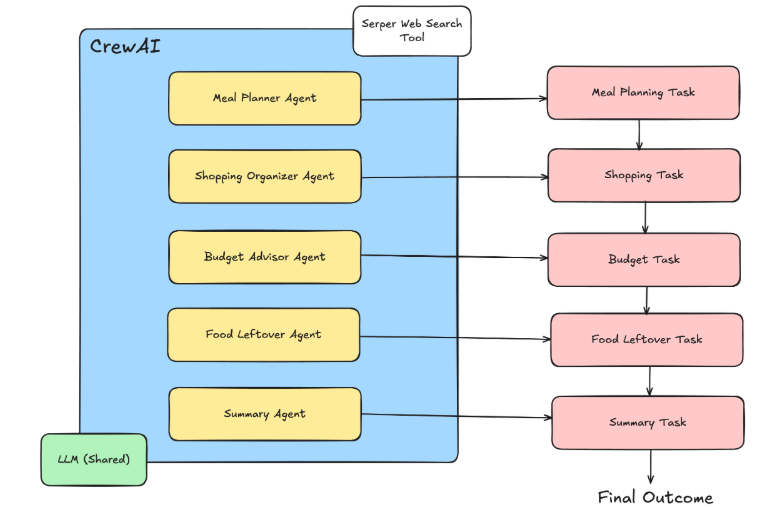

##### Creating our AI AGent workflow with CrewAI

In [19]:
# meal planner agent
meal_planner = Agent(
    role="Meal Planner & Recipe Researcher",
    goal="Search for optimal recipes and create detailed meal plans",
    backstory="A skilled meal planner who researches the best recipes online, considering dietary needs, cooking skill levels, and budget constraints.",
    tools=[SerperDevTool()],
    llm=llm,
    verbose=False
)

# meal planner task
meal_planning_task = Task(
    description=(
        "Search for the best '{meal_name}' recipe for {servings} people within a {budget} budget. "
        "Consider dietary restrictions: {dietary_restrictions} and cooking skill level: {cooking_skill}. "
        "Find recipes that match the skill level and provide complete ingredient lists with quantities."
    ),
    expected_output="A detailed meal plan with researched ingredients, quantities, and cooking instructions appropriate for the skill level.",
    agent=meal_planner,
    output_pydantic=MealPlan,
    output_file="meals.json"
)

ValidationError: 2 validation errors for Agent
llm.str
  Input should be a valid string [type=string_type, input_value=ChatGoogleGenerativeAI(me...ata=(), model_kwargs={}), input_type=ChatGoogleGenerativeAI]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type
llm.BaseLLM
  Input should be a valid dictionary or instance of BaseLLM [type=model_type, input_value=ChatGoogleGenerativeAI(me...ata=(), model_kwargs={}), input_type=ChatGoogleGenerativeAI]
    For further information visit https://errors.pydantic.dev/2.12/v/model_type

Create and running our meal planner crew

In [20]:
from crewai import Crew, Process

meal_planner_crew = Crew(
    agents=[meal_planner],
    tasks=[meal_planning_task],
    process=Process.sequential,  # Ensures tasks are executed in order
    verbose=True
)

meal_planner_result = meal_planner_crew.kickoff(
    inputs={
        "meal_name": "Chicken Stir Fry",
        "servings": 4,
        "budget": "$25",                           
        "dietary_restrictions": ["no nuts"],       
        "cooking_skill": "beginner"                
    }
)
print("✅ Single meal planning completed!")
print("📋 Single Meal Results:")
print(meal_planner_result)

NameError: name 'meal_planner' is not defined

<b>Creating our Shopping Organization Agent


In [21]:
shopping_organizer = Agent(
    role="Shopping Organizer", 
    goal="Organize grocery lists by store sections efficiently",
    backstory="An experienced shopper who knows how to organize lists for quick store trips and considers dietary restrictions.",
    tools=[],
    llm=llm,
    verbose=False
)

shopping_task = Task(
    description=(
        "Organize the ingredients from the '{meal_name}' meal plan into a grocery shopping list. "
        "Group items by store sections and estimate quantities for {servings} people. "
        "Consider dietary restrictions: {dietary_restrictions} and cooking skill: {cooking_skill}. "
        "Stay within budget: {budget}."
    ),
    expected_output="An organized shopping list grouped by store sections with quantities and prices.",
    agent=shopping_organizer,
    context=[meal_planning_task],
    output_pydantic=GroceryShoppingPlan,
    output_file="shopping_list.json"
)

ValidationError: 2 validation errors for Agent
llm.str
  Input should be a valid string [type=string_type, input_value=ChatGoogleGenerativeAI(me...ata=(), model_kwargs={}), input_type=ChatGoogleGenerativeAI]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type
llm.BaseLLM
  Input should be a valid dictionary or instance of BaseLLM [type=model_type, input_value=ChatGoogleGenerativeAI(me...ata=(), model_kwargs={}), input_type=ChatGoogleGenerativeAI]
    For further information visit https://errors.pydantic.dev/2.12/v/model_type

<B>Building our Two-Agent Grocery Crew

In [22]:
two_agent_grocery_crew = Crew(
    agents=[meal_planner, shopping_organizer],  # Both agents
    tasks=[meal_planning_task, shopping_task],   # Both tasks
    process=Process.sequential,
    verbose=True
)

# Run the complete crew (this will do BOTH meal planning AND shopping)
shopping_result = two_agent_grocery_crew.kickoff(
    inputs={
        "meal_name": "Chicken Stir Fry",
        "servings": 4,
        "budget": "$25",                           
        "dietary_restrictions": ["no nuts"],      
        "cooking_skill": "beginner"               
    }
)

# Print the shopping results
print("✅ Complete meal planning + shopping completed!")
print("📋 Shopping Results:")
print(shopping_result)

NameError: name 'meal_planner' is not defined

<b>Adding Financial Intelligent with Budget Advirsor Agent

In [25]:
budget_advisor = Agent(
    role="Budget Advisor",
    goal="Provide cost estimates and money-saving tips",
    backstory="A budget-conscious shopper who helps families save money on groceries while respecting dietary needs.",
    tools=[SerperDevTool()],
    llm=llm,
    verbose=False
)


budget_task = Task(
    description=(
        "Analyze the shopping plan for '{meal_name}' serving {servings} people. "
        "Ensure total cost stays within {budget}. Consider dietary restrictions: {dietary_restrictions}. "
        "Provide practical money-saving tips and alternative ingredients if needed to meet budget."
    ),
    expected_output="A complete shopping guide with detailed prices, budget analysis, and money-saving tips.",
    agent=budget_advisor,
    context=[meal_planning_task, shopping_task],
    output_file="shopping_guide.md"
)


ValidationError: 2 validation errors for Agent
llm.str
  Input should be a valid string [type=string_type, input_value=ChatGoogleGenerativeAI(me...ata=(), model_kwargs={}), input_type=ChatGoogleGenerativeAI]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type
llm.BaseLLM
  Input should be a valid dictionary or instance of BaseLLM [type=model_type, input_value=ChatGoogleGenerativeAI(me...ata=(), model_kwargs={}), input_type=ChatGoogleGenerativeAI]
    For further information visit https://errors.pydantic.dev/2.12/v/model_type

<b>Using YAML with CrewAI - Food Leftover agent and task


In [ ]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/-5NXnHGkX1WG81tqE8kSTg/agents.yaml"

In [29]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/7fhq1KPxi7cuqjOCBgcmXQ/tasks.yaml"

SyntaxError: invalid syntax (389838459.py, line 1)

<b>Using CrewBase & Decorator with CrewAI

in CrewAI, @CrewBase is python class decorator that automates the collection and wirirng of oura agents and tasks , especially when we are organinzing our crew logic in python, YAML, or hybrid config (YAML + code)

In [30]:
from leftover import LeftoversCrew

leftovers_cb = LeftoversCrew(llm=llm)
yaml_leftover_manager = leftovers_cb.leftover_manager()
yaml_leftover_task    = leftovers_cb.leftover_task()

KeyError: 'leftover_manager'

<b>Defining our Summary Agent and Task

In [31]:
summary_agent = Agent(
    role="Report Compiler",
    goal="Compile comprehensive meal planning reports from all team outputs",
    backstory="A skilled coordinator who organizes information from multiple specialists into comprehensive, easy-to-follow reports.",
    tools=[],
    llm=llm,
    verbose=False
)

summary_task = Task(
    description=(
        "Compile a comprehensive meal planning report that includes:\n"
        "1. The complete recipe and cooking instructions from the meal planner\n"
        "2. The organized shopping list with prices from the shopping organizer\n"
        "3. The budget analysis and money-saving tips from the budget advisor\n"
        "4. The leftover management suggestions from the waste reduction specialist\n"
        "Format this as a complete, user-friendly meal planning guide."
    ),
    expected_output="A comprehensive meal planning guide that combines all team outputs into one cohesive report.",
    agent=summary_agent,
    context=[meal_planning_task, shopping_task, budget_task, yaml_leftover_task],
)

ValidationError: 2 validation errors for Agent
llm.str
  Input should be a valid string [type=string_type, input_value=ChatGoogleGenerativeAI(me...ata=(), model_kwargs={}), input_type=ChatGoogleGenerativeAI]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type
llm.BaseLLM
  Input should be a valid dictionary or instance of BaseLLM [type=model_type, input_value=ChatGoogleGenerativeAI(me...ata=(), model_kwargs={}), input_type=ChatGoogleGenerativeAI]
    For further information visit https://errors.pydantic.dev/2.12/v/model_type

<b>Assembling our Complete Grocery Planning team

In [32]:
complete_grocery_crew = Crew(
    agents=[
        meal_planner,           
        shopping_organizer,      
        budget_advisor,         
        yaml_leftover_manager,  # YAML-based leftover manager
        summary_agent           # New summary agent
    ],
    tasks=[
        meal_planning_task,     
        shopping_task,          
        budget_task,            
        yaml_leftover_task,    # YAML-based leftover task
        summary_task            # New summary task
    ],
    process=Process.sequential,
    verbose=True
)

NameError: name 'meal_planner' is not defined

<b>Executing our complete grocery Planning workflow

In [ ]:
# Run the complete crew
complete_result = complete_grocery_crew.kickoff(
    inputs={
        "meal_name": "Chicken Stir Fry",
        "servings": 4,
        "budget": "$25",
        "dietary_restrictions": ["no nuts", "low sodium"],
        "cooking_skill": "beginner"
    }
)

print("✅ Complete meal planning with summary completed!")
print("📋 Complete Results:")
print(complete_result)